In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import yaml

dataset_dir = '/content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8'

yaml_path = f'{dataset_dir}/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = f'{dataset_dir}/train/images'
data['val'] = f'{dataset_dir}/valid/images'
data['test'] = f'{dataset_dir}/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml dosyası tam yollarla güncellendi!")

data.yaml dosyası tam yollarla güncellendi!


In [4]:
!pip install ultralytics

from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='/content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    name='yoda_modeli'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.236 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript

--- EĞİTİM SONUÇLARI ---

Confusion Matrix (Karmaşıklık Matrisi):


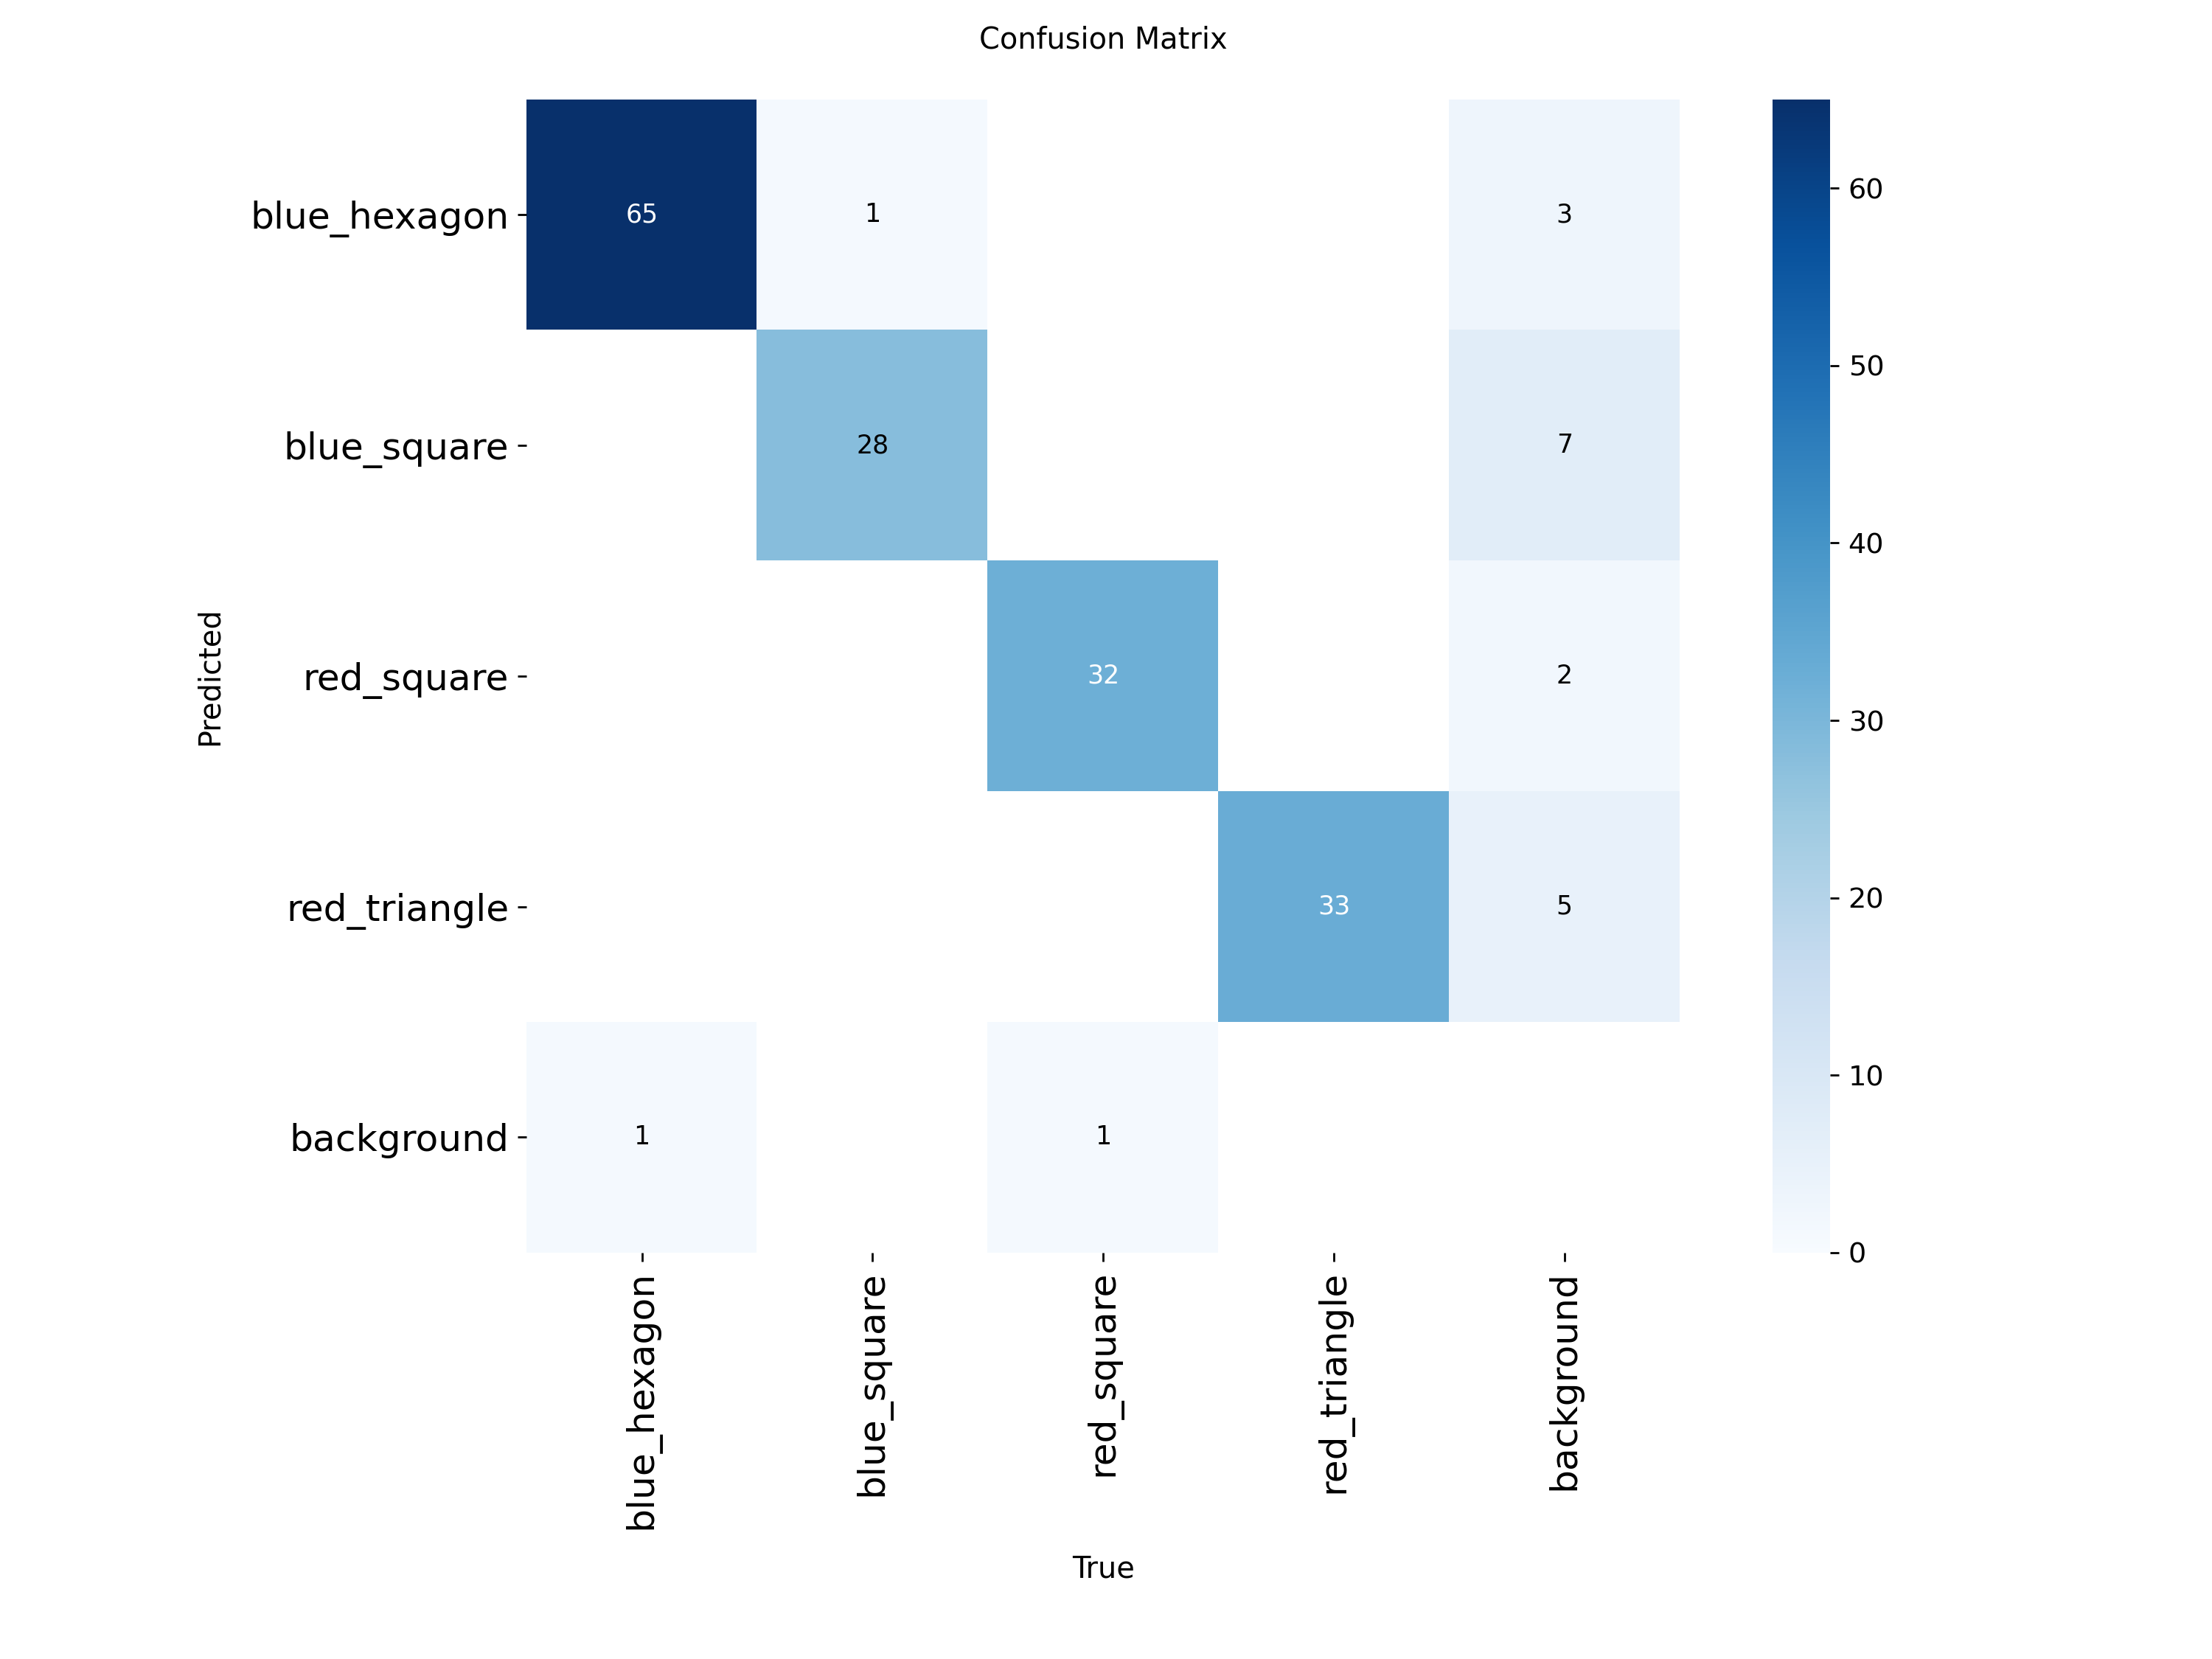


Genel Eğitim Başarısı (Loss & mAP):


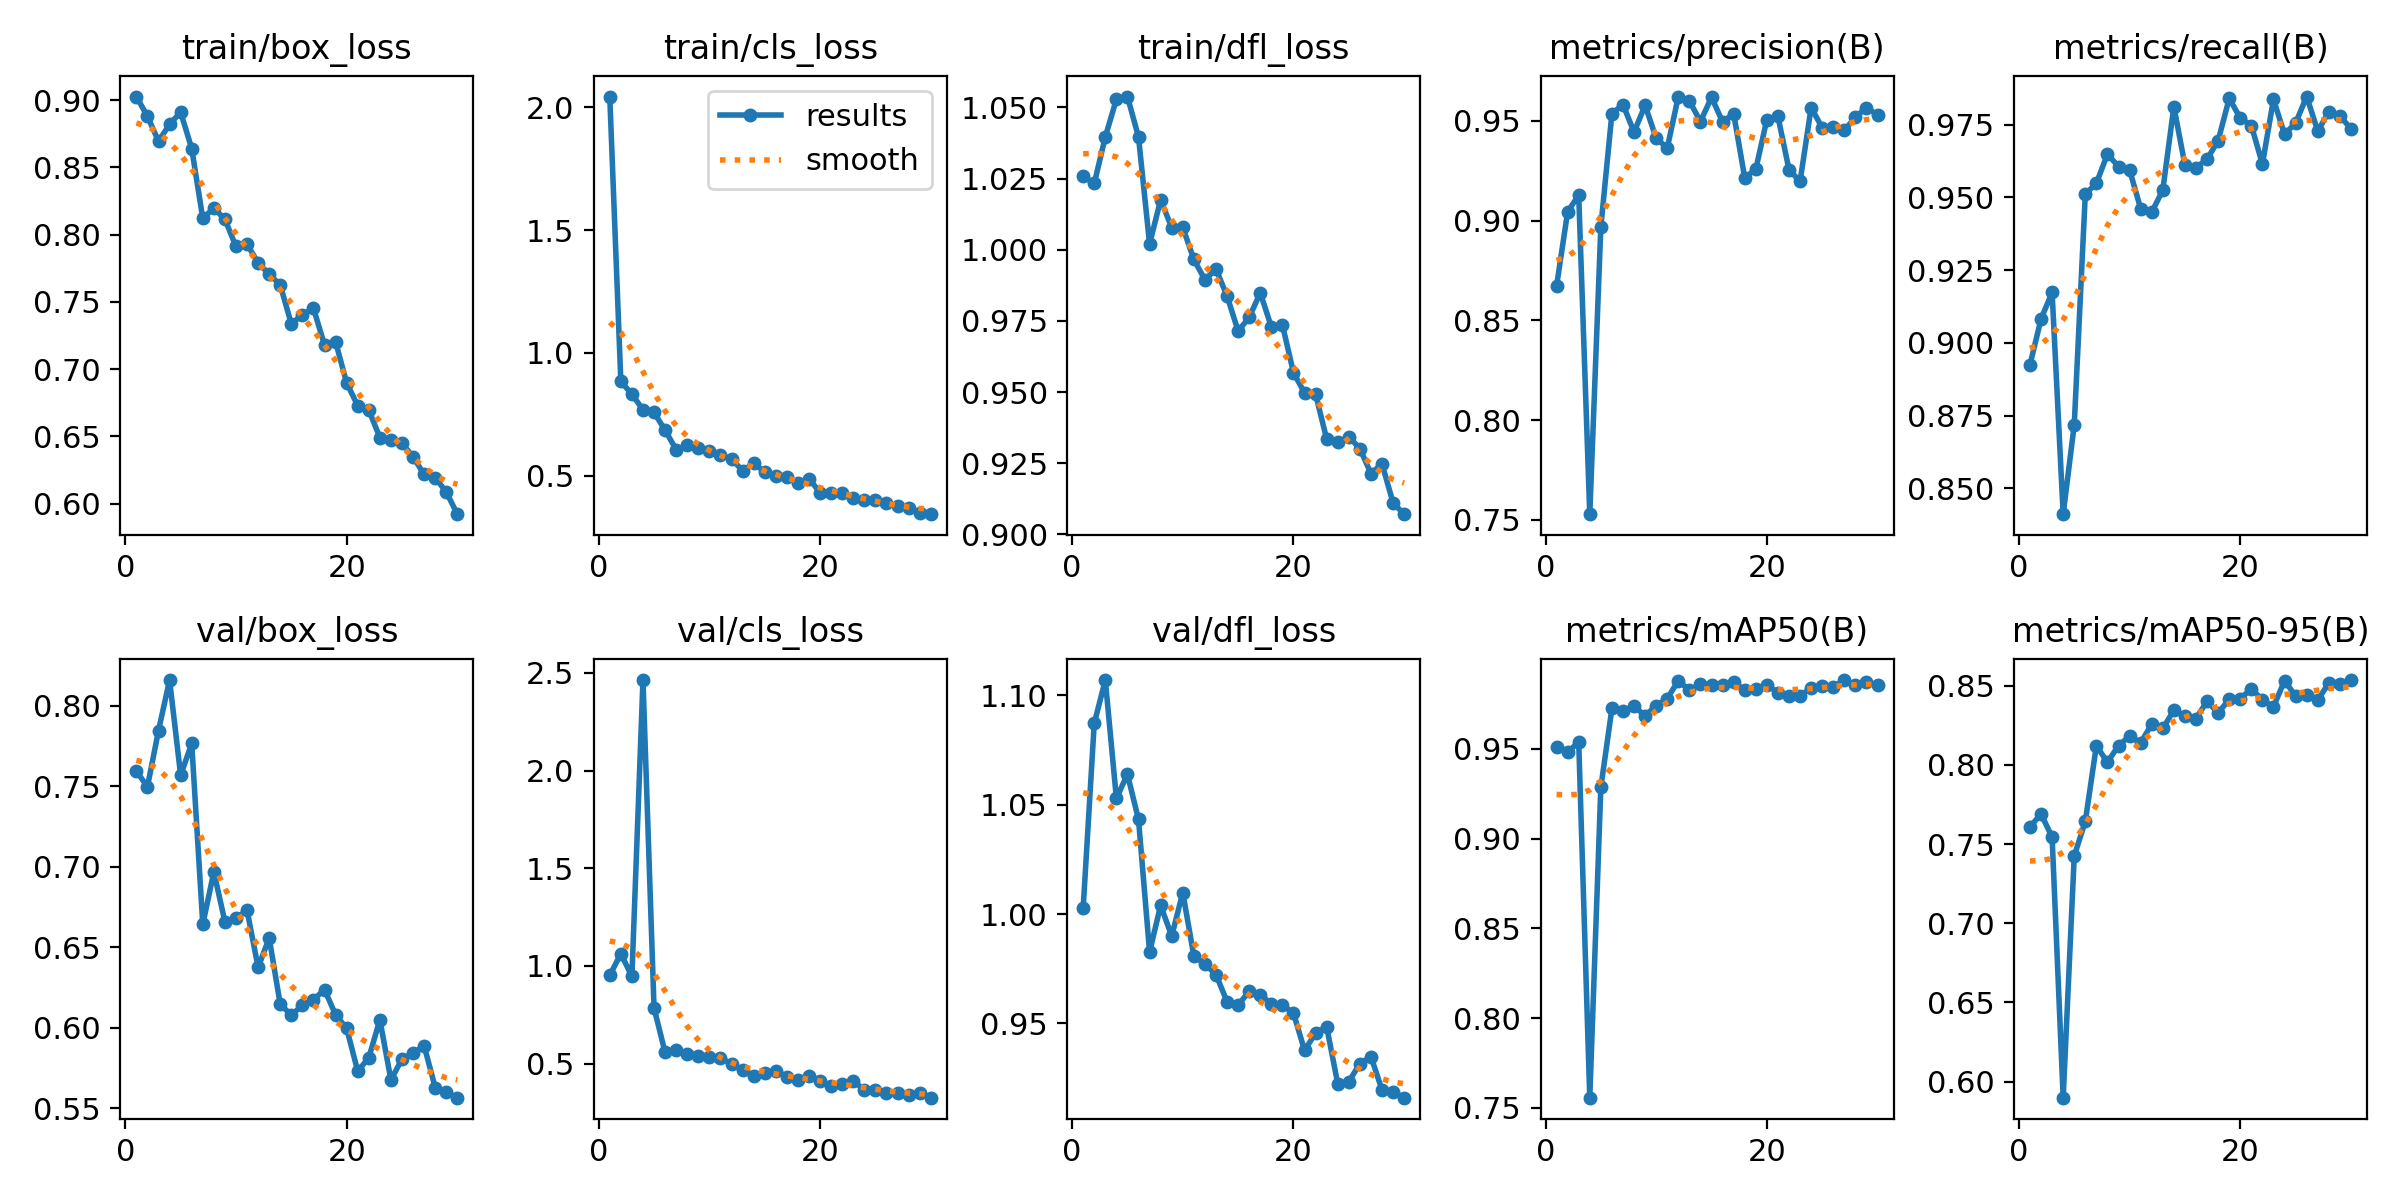

In [5]:
from IPython.display import Image, display
import os

results_dir = '/content/runs/detect/yoda_modeli'

print("--- EĞİTİM SONUÇLARI ---")

conf_mat = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(conf_mat):
    print("\nConfusion Matrix (Karmaşıklık Matrisi):")
    display(Image(filename=conf_mat, width=600))
else:
    print("Confusion Matrix bulunamadı (Eğitim tam bitmemiş veya hata almış olabilir).")

results_img = os.path.join(results_dir, 'results.png')
if os.path.exists(results_img):
    print("\nGenel Eğitim Başarısı (Loss & mAP):")
    display(Image(filename=results_img, width=800))


image 1/1 /content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8/valid/images/28_Temmuz_Ucus_2_2_frame_0332_jpg.rf.076f04cf697de6e52fc505d2213fb328.jpg: 640x640 1 red_triangle, 16.2ms
Speed: 2.1ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


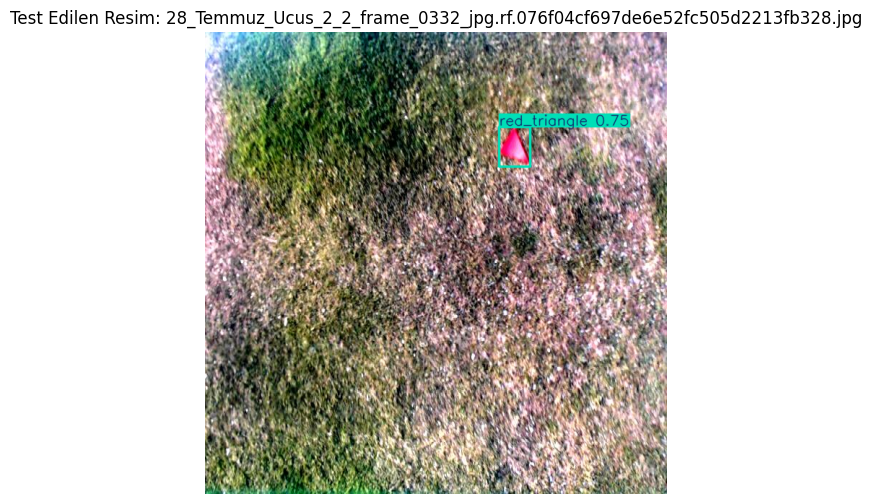


image 1/1 /content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8/valid/images/28_Temmuz_Ucus_2_3_frame_0992_jpg.rf.4817ef6be2aa4604eb485b6a8251d3b2.jpg: 640x640 1 blue_hexagon, 1 red_square, 16.3ms
Speed: 2.1ms preprocess, 16.3ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


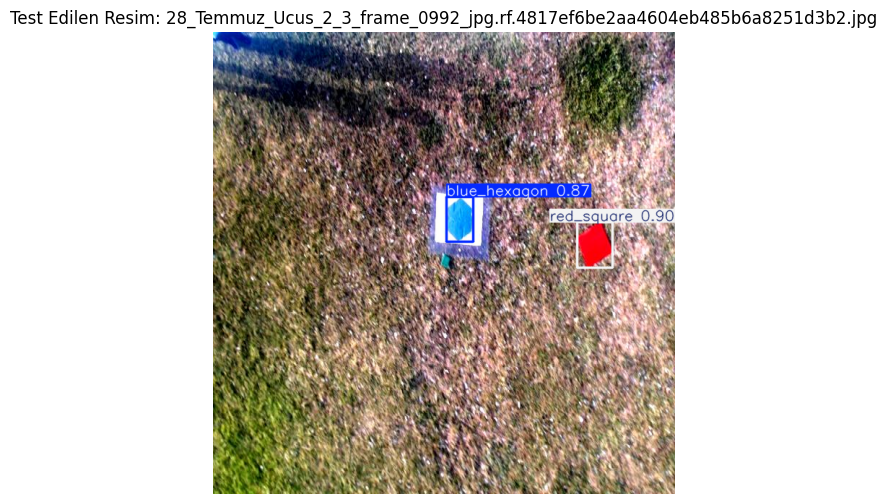


image 1/1 /content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8/valid/images/28_Temmuz_Ucus_2_2_frame_0339_jpg.rf.d992ffaa968311b717fa17f61a98a455.jpg: 640x640 1 red_square, 17.7ms
Speed: 2.2ms preprocess, 17.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


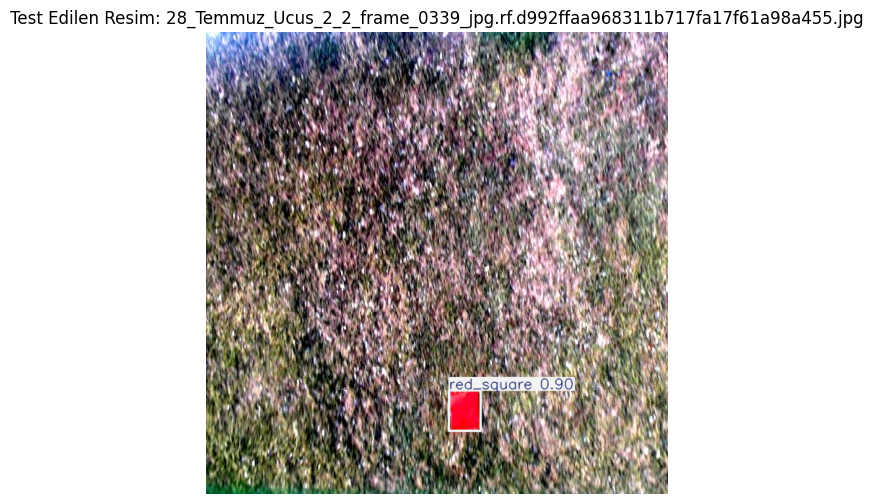

In [6]:
import random
import cv2
import matplotlib.pyplot as plt

val_images_path = '/content/drive/MyDrive/yoda_odevlendirme_veriseti.yolov8/valid/images'

random_files = random.sample(os.listdir(val_images_path), 3)

best_model = YOLO(f'{results_dir}/weights/best.pt')

for file_name in random_files:
    img_path = os.path.join(val_images_path, file_name)

    results = best_model.predict(source=img_path, conf=0.40, save=False)

    result_plot = results[0].plot()

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result_plot, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Test Edilen Resim: {file_name}")
    plt.show()